___

# Machine Learning in Geosciences ] 
Department of Applied Geoinformatics and Carthography, Charles University

Lukas Brodsky lukas.brodsky@natur.cuni.cz


### PyTorch installation

`pip install torch`
`pip install torchvision`

### PyTorch tensor

Tensors are the building blocks for representing data in PyThorch. It is the fundamental data structure. The term `tensor` comes bundled with the notion of spaces. In this context of deep learning, tensors refer to the generalization of vectors and matrices to an arbitrary number of dimensions. 

The torch package contains not only the data structures for **multi-dimensional arrays** but also defines mathematical operations over these tensors. Additionally, it provides many utilities for efficient serializing of Tensors and arbitrary types, and other useful utilities.

### PyTorch tensor vs. NumPy array

What is the difference between numpy array and pytorch tensor?

1. The numpy arrays are the core functionality of the numpy package designed to support faster mathematical operations. Pytorch tensors are similar to numpy arrays, but can also be operated on CUDA-capable Nvidia GPU.
   
   
2. Numpy arrays are mainly used in typical machine learning algorithms. Pytorch tensors are mainly used in deep learning which requires heavy matrix computation.

3. Unlike numpy arrays, while creating pytorch tensor, it also accepts two other arguments called the device_type (whether the computation happens on CPU or GPU) and the requires_grad (which is used to compute the derivatives).

### PyTorch API

The PyTorch API establish a few directions on where to find things in the documentation (https://pytorch.org/docs/stable/index.html). 

**Topics covered**: 

    1. What is the difference between numpy array and pytorch tensor?

    2. How to create numpy arrays and pytorch tensors. Furthermore, we will see how to perform the same operation on both data types.
    
    

In [1]:
print(1)

1


In [2]:
import torch 
import numpy as np

### Constructors

In [3]:
# Creaty NumPy arrays
array1 = np.array([1,2,3,4])
# from list
list1 = [[1,2,3,4],[5,6,7,8]]
array2 = np.array(list1)
# casting data type
array3 = np.array([1,2,3,4], dtype=np.float64)
type(array1), array1.dtype

(numpy.ndarray, dtype('int64'))

#### Create PyTorch Tensor from list and NumPy array

Use constructor `torch.tensor()`

In [4]:
# PyTorch Tensor 
# from list 
tensor1 = torch.tensor([1,2,3,4])
# from NumPy array 
numpy_arr1 = np.array([11,21,322])
tensor2 = torch.tensor(numpy_arr1)
type(tensor1), tensor2.dtype

(torch.Tensor, torch.int64)

In [5]:
# from tensor to array 
numpy_arr = tensor1.numpy()
numpy_arr

array([1, 2, 3, 4])

In [6]:
# see what happen if you overwrite element in array
numpy_arr[1] = 999
tensor1, numpy_arr

(tensor([  1, 999,   3,   4]), array([  1, 999,   3,   4]))

In [7]:
# from array to tensor 
array1_tensor = torch.from_numpy(array1)
array1_tensor

tensor([1, 2, 3, 4])

### Random function

In [8]:
np.random.rand(2, 3) # numpy way

array([[0.89070856, 0.00984659, 0.03758291],
       [0.91629229, 0.65989713, 0.96960572]])

In [9]:
torch.rand(2, 3) # pytorch way

tensor([[0.8985, 0.9356, 0.2639],
        [0.1312, 0.4430, 0.8472]])

### Seed function

In [10]:
np.random.seed(42)
np.random.rand(2)

array([0.37454012, 0.95071431])

In [11]:
torch.manual_seed(42) # for both CPU and CUDA
torch.rand(2)

tensor([0.8823, 0.9150])

### Reshaping the array

In [12]:
# numpy approach 
np_arr = np.array([1, 2, 3, 4, 5, 6, 7, 8])
np_arr.shape

(8,)

In [13]:
new_arr = np_arr.reshape(2, 2, -1) 
new_arr.shape

(2, 2, 2)

In [14]:
new_arr

array([[[1, 2],
        [3, 4]],

       [[5, 6],
        [7, 8]]])

In [15]:
# reshape tensor 
tensor1 = torch.tensor([1, 2, 3, 4, 5, 6, 7, 8])
tensor1.reshape(2, 2, -1)

tensor([[[1, 2],
         [3, 4]],

        [[5, 6],
         [7, 8]]])

Note that there are two functions in pytorch to `reshape` the array. One is `permute` which basically permutes the dimensions without changing the data ordering and other is reshape which just changes the size to the desired size and so the ordering of elements get changed.

In [16]:
x = torch.randn(2, 5)
x

tensor([[ 0.4740,  0.1978,  1.1561,  0.3965, -2.4661],
        [ 0.3623,  0.3765, -0.1808,  0.3930,  0.4327]])

In [17]:
x.permute(1, 0)

tensor([[ 0.4740,  0.3623],
        [ 0.1978,  0.3765],
        [ 1.1561, -0.1808],
        [ 0.3965,  0.3930],
        [-2.4661,  0.4327]])

In [18]:
x.permute(0, 1)

tensor([[ 0.4740,  0.1978,  1.1561,  0.3965, -2.4661],
        [ 0.3623,  0.3765, -0.1808,  0.3930,  0.4327]])

In [19]:
# reshape method has changes the order of elements
x.reshape(5, 2)

tensor([[ 0.4740,  0.1978],
        [ 1.1561,  0.3965],
        [-2.4661,  0.3623],
        [ 0.3765, -0.1808],
        [ 0.3930,  0.4327]])

In [20]:
x.storage() 

C:\Users\Oleksandr\AppData\Local\Temp\ipykernel_14380\192378810.py:1: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  x.storage()


 0.47404009103775024
 0.19778664410114288
 1.1561247110366821
 0.3964806795120239
 -2.466057062149048
 0.36228621006011963
 0.3765491247177124
 -0.18080879747867584
 0.39302995800971985
 0.4327020049095154
[torch.storage.TypedStorage(dtype=torch.float32, device=cpu) of size 10]

### Slicing the arrays

In [21]:
x = torch.rand(3, 4)
x[:, 2] = 23 # Replace every element of third column to 23
print(x)

tensor([[2.9692e-01, 8.3169e-01, 2.3000e+01, 2.6949e-01],
        [3.5881e-01, 1.9936e-01, 2.3000e+01, 6.1604e-03],
        [9.5155e-01, 7.5266e-02, 2.3000e+01, 5.8321e-01]])


In [22]:
y = np.random.rand(3, 4)
y[:, 2] = 223 # Replace every element of third column to 223
print(y)

[[7.31993942e-01 5.98658484e-01 2.23000000e+02 1.55994520e-01]
 [5.80836122e-02 8.66176146e-01 2.23000000e+02 7.08072578e-01]
 [2.05844943e-02 9.69909852e-01 2.23000000e+02 2.12339111e-01]]


In [23]:
x[0] = 999 # Replace every element of first row to 999
print(x)

tensor([[9.9900e+02, 9.9900e+02, 9.9900e+02, 9.9900e+02],
        [3.5881e-01, 1.9936e-01, 2.3000e+01, 6.1604e-03],
        [9.5155e-01, 7.5266e-02, 2.3000e+01, 5.8321e-01]])


In [24]:
y[0] = 9999 # Replace every element of first row to 9999
print(y)

[[9.99900000e+03 9.99900000e+03 9.99900000e+03 9.99900000e+03]
 [5.80836122e-02 8.66176146e-01 2.23000000e+02 7.08072578e-01]
 [2.05844943e-02 9.69909852e-01 2.23000000e+02 2.12339111e-01]]


## Linear ALgebra

In [25]:
# Scalars
x = torch.tensor(3.0)
y = torch.tensor(2.0)

x + y, x * y, x / y, x**y

(tensor(5.), tensor(6.), tensor(1.5000), tensor(9.))

In [26]:
# Vectors
x = torch.arange(3)
x

tensor([0, 1, 2])

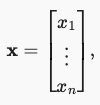

In [27]:
x.shape

torch.Size([3])

In [28]:
# Matrices
A = torch.arange(6).reshape(3, 2)
A

tensor([[0, 1],
        [2, 3],
        [4, 5]])

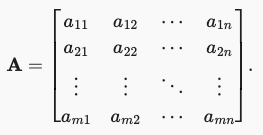



#### Matrix transpose

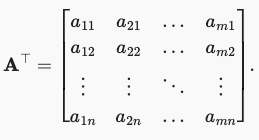

In [29]:
A.T

tensor([[0, 2, 4],
        [1, 3, 5]])

In [30]:
# Tensors 
# Tensors give us a generic way of describing extensions to -order arrays. 
# We call software objects of the tensor class “tensors” precisely because 
# they too can have arbitrary numbers of axes. 
torch.arange(24).reshape(2, 3, 4)

tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]],

        [[12, 13, 14, 15],
         [16, 17, 18, 19],
         [20, 21, 22, 23]]])

In [31]:
# Aritmetic
A = torch.arange(6, dtype=torch.float32).reshape(2, 3)
B = A.clone()  # Assign a copy of A to B by allocating new memory
A, A + B

(tensor([[0., 1., 2.],
         [3., 4., 5.]]),
 tensor([[ 0.,  2.,  4.],
         [ 6.,  8., 10.]]))

In [32]:
# The elementwise product of two matrices is called their Hadamard product. 
# We can spell out the entries of the Hadamard product of two matrices A, B:
A * B

tensor([[ 0.,  1.,  4.],
        [ 9., 16., 25.]])

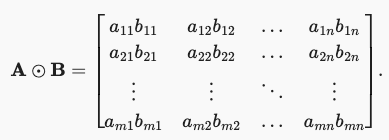

In [33]:
# Adding or multiplying a scalar and a tensor produces a result 
# with the same shape as the original tensor.

a = 2
X = torch.arange(24).reshape(2, 3, 4)
a + X, (a * X).shape

(tensor([[[ 2,  3,  4,  5],
          [ 6,  7,  8,  9],
          [10, 11, 12, 13]],
 
         [[14, 15, 16, 17],
          [18, 19, 20, 21],
          [22, 23, 24, 25]]]),
 torch.Size([2, 3, 4]))

In [34]:
X.shape

torch.Size([2, 3, 4])

In [35]:
# Dot product 
# The most fundamental operations is the dot product. Given two vectors x, y, their dot product 
# (also known as inner product, ) is a sum over the products of the elements at the same position: 
x = torch.arange(3, dtype=torch.float32)
y = torch.ones(3, dtype = torch.float32)

x, y, torch.dot(x, y)

(tensor([0., 1., 2.]), tensor([1., 1., 1.]), tensor(3.))

In [36]:
# Matrix-vector products 
A.shape, x.shape, torch.mv(A, x), A@x

(torch.Size([2, 3]), torch.Size([3]), tensor([ 5., 14.]), tensor([ 5., 14.]))

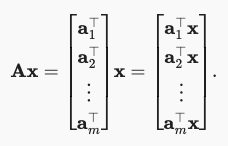

In [37]:
# Matrix–Matrix Multiplication 
B = torch.ones(3, 4)
A.shape, B.shape

(torch.Size([2, 3]), torch.Size([3, 4]))

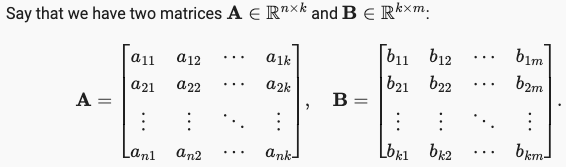

We simply compute each element as the dot product. 

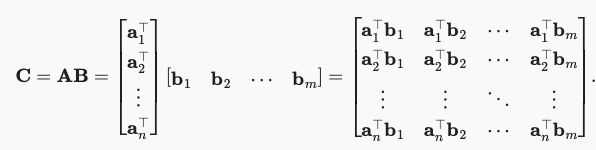

In [38]:
torch.mm(A, B), A@B

(tensor([[ 3.,  3.,  3.,  3.],
         [12., 12., 12., 12.]]),
 tensor([[ 3.,  3.,  3.,  3.],
         [12., 12., 12., 12.]]))

In [39]:
C = A@B
C.shape

torch.Size([2, 4])

In [ ]:
# Norms 
# Some of the most useful operators in linear algebra are norms. Informally, the norm of a vector tells us how big it is. 
# For instance, the norm measures the (Euclidean) length of a vector. 
# A norm is a function that maps a vector to a scalar. 

In [40]:
# l2 norm
u = torch.tensor([3.0, -4.0])
torch.norm(u)

tensor(5.)

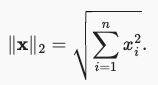

In [41]:
# l1 norm ~ Manhatten 
torch.abs(u).sum()

tensor(7.)

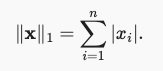

### Calculus 

In [42]:
# Derivative of a function 
def f(x):
    return 3 * x ** 2 - 4 * x



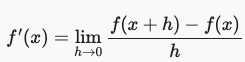

In [43]:
for h in 10.0**np.arange(-1, -6, -1):
    print(f'h={h:.5f}, numerical limit={(f(1+h)-f(1))/h:.5f}')

h=0.10000, numerical limit=2.30000
h=0.01000, numerical limit=2.03000
h=0.00100, numerical limit=2.00300
h=0.00010, numerical limit=2.00030
h=0.00001, numerical limit=2.00003


In [ ]:
# Recall that calculating derivatives is the crucial step in all the optimization algorithms 
# that we will use to train deep networks.
# Fortunately all modern deep learning frameworks take this work off our plates by offering automatic differentiation 
# (often shortened to autograd). 

In [44]:
# Let’s assume that we are interested in differentiating the y = 2xTx function with respect to the column vector x.
x = torch.arange(4.0)
x

tensor([0., 1., 2., 3.])

In [45]:
# Can also create x = torch.arange(4.0, requires_grad=True)
x.requires_grad_(True)
x.grad  # The gradient is None by default

In [46]:
x

tensor([0., 1., 2., 3.], requires_grad=True)

In [47]:
# We now calculate our function of x and assign the result to y. 
y = 2 * torch.dot(x, x)
y

tensor(28., grad_fn=<MulBackward0>)

In [48]:
# We can now take the gradient of y with respect to x by calling its backward method. 
# Next, we can access the gradient via x’s grad attribute. 
y.backward()
x.grad

tensor([ 0.,  4.,  8., 12.])

In [49]:
# We know that the gradient of the function y = 2xTx  with respect to x should be 4x. 
# We can now verify that the automatic gradient computation and the expected result are identical.

x.grad == 4 * x

tensor([True, True, True, True])

In [50]:
# Now let’s calculate another function of x and take its gradient. 
# Note that PyTorch does not automatically reset the gradient buffer when we record a new gradient. 
# Instead, the new gradient is added to the already-stored gradient. This behavior comes in handy when 
# we want to optimize the sum of multiple objective functions. 
# To reset the gradient buffer, we can call x.grad.zero_() as follows:

x.grad.zero_()  # Reset the gradient
y = x.sum()
y.backward()
x.grad

tensor([1., 1., 1., 1.])

In [51]:
# Backward 
# When y is a vector, the most natural representation of the derivative of y with respect to a vector x is a matrix 
# called the Jacobian that contains the partial derivatives of each component of y with respect to each component of x. 

x.grad.zero_()
y = x * x
y.backward(gradient=torch.ones(len(y)))  # Faster: y.sum().backward()
x.grad

tensor([0., 2., 4., 6.])

In [52]:
# Detaching Computation
# Sometimes, we wish to move some calculations outside of the recorded computational graph. For example, say that we use the input to create some auxiliary intermediate terms 
# for which we do not want to compute a gradient. 

x.grad.zero_()
y = x * x
u = y.detach()
z = u * x

z.sum().backward()
x.grad == u

tensor([True, True, True, True])